In [1]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from diffusion_on_the_edge.core.grid import TimeGrid
from diffusion_on_the_edge.processes import OUNumpy, OUParamsNP, OUTorch, OUTorchParams
from diffusion_on_the_edge.sde.np_backend import simulate_sde_np

# Diffusion models - Introduction

Welcome!

This is a first part of a two-part series on diffusion models. Our end goal is to understand the paper __paper_name_here deeply, starting from the basic building blocks of diffusion models.

This first introductory part guides you through the basic building blocks of diffusion models, starting from the continuous stochastic process. From there, we describe the mechanisms of reversing the process and show how neural networks are utilized in solving a backwards stochastic differential equation. Alongside solving the forward and backward stochastic differential equations, we show how the probability density flows from the initial configuration into the more evenly distributed end-state distribution. Analogous to the stochastic case, we also show how to reverse this probability flow using a learned model.

The steps we will take in this blog post are:

1. Review of stochastic processes
2. Density flow
3. Backwards stochastic process
4. Inverting the density flow
5. Implementing a score model
6. Simple 2-dimensional example

# Review of stochastic processes

As a quick review, we define a stochastic process to be a process of real-valued random variables $X_t \in \mathbb{R}^d$, where $t \in [0, 1]$ and $d$ denotes the dimensionality of the random process. In practice and for visualization purposes, we usually deal with random processes in dimension $d = 1, 2$ or $3$. Also, let $p_t$ denote the probability density of $X_t$ at time $t$.

An example of a stochastic process is geometric brownian motion, $dX_t = \sigma dW_t, \sigma \gt 0$, where $dW_t$ denotes the standard $d$-dimensional brownian noise. We often characterize a stochastic process as a stochastic differential equation, $dX_t = (\text{something })dt + (\text{something else })dW_t$, with a deterministic part describing the general trend, an a stochastic noise part which describes the deviation of that trend.

The particular stochastic process which we utilize in this blog post is an Ornstein–Uhlenbeck process, also shortened as an OU process. An OU process has a form like

$$
dX_t = -\lambda X_t dt + \sigma dW_t
$$

where $\lambda > 0$ and $\sigma > 0$ are simple constants.

## Example of an Ornstein-Uhlenbeck process

Beginning with a simple example, suppose we have a 2-dimensional diffusion process ($d = 2$) with a starting dataset $X_0$ composed of two ring shaped distributions.

In [2]:
def generate_example_dataset(n=5000, noise=0.01):
    circle_radius = 1.4
    second_radius = 0.5
    points = []
    for theta in np.linspace(0, np.pi, int(n // 2)):
        points.append([circle_radius * np.cos(theta) + 0.6, 0.2 + circle_radius * np.sin(theta)])
        points.append([second_radius * np.cos(theta + np.pi) - 0.5, second_radius * np.sin(theta + np.pi) - 1.0])

    # Add Gaussian noise
    points = np.array(points)
    points += np.random.normal(scale=noise, size=points.shape)

    return points


N = 2048
noise = 0.02
dataset = generate_example_dataset(n = N, noise = noise)
dataset.shape

(2048, 2)

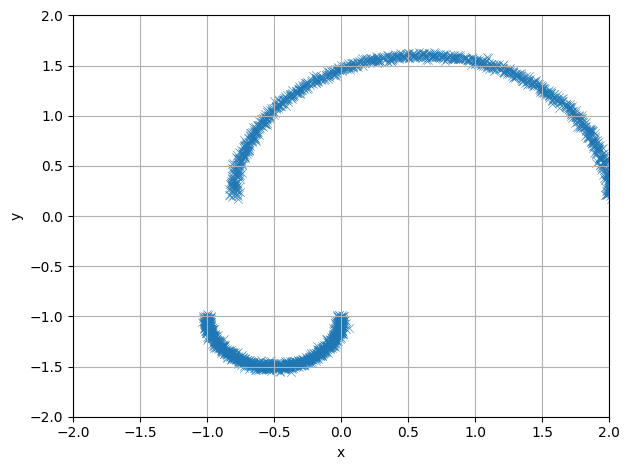

In [3]:
sns.scatterplot(x = dataset[:, 0], y = dataset[:, 1], alpha = 0.8, marker = 'x').set(xlim=(-2, 2), ylim=(-2,2), xlabel='x', ylabel='y')
plt.grid()
plt.tight_layout()

We can now apply an OU diffusion process with specific parameters $\lambda = 0.4, \sigma = 0.5$ and visualize it as an animation. The animation shows how the initial dataset gets diffused into a pointcloud with no discernable features.

In [4]:
process_params = OUParamsNP(dim = 2, theta = 0.5, mu = 0, sigma = 0.5)
process = OUNumpy(params=process_params)
grid = TimeGrid(t0=0, t1=1, N = 101)

X_t, times = simulate_sde_np(process, x0=dataset, grid = grid, method='exact')
X_t.shape

(101, 2048, 2)

In [5]:
from IPython.display import HTML
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(8, 6))
scat = ax.scatter([], [], s=5)
cmap = plt.get_cmap('tab10')

def init():
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_title("Evolution of diffusion process $X_t$")
    ax.set_ylabel('$y$')
    ax.set_xlabel('$x$')
    return scat,

def update(frame):
    scat.set_offsets(X_t[frame])
    ax.set_title(f"t = {times[frame]:.2f}")
    return scat,

ani = animation.FuncAnimation(fig, update, frames=X_t.shape[0] - 1, init_func=init,
                              interval=100, blit=True)
plt.grid()
plt.close(fig)
ani.save('./assets/animation_forward.mp4')

<video width="360" height="280" controls>
  <source src="./assets/animation_forward.mp4" type="video/mp4">
</video>

As we can see, the animation shows how the initial dataset gets distorted into a gaussian blob.

# Density flow

An OU process has a nice equivalent formulation; the probability distribution of such a process, $p = p(x, t) = p_t(x)$, has to satisfy a particular equation. The equation is known as a Fokker-Planck equation, being a partial differential equation for the density function $p$.

$$
\frac{\partial}{\partial t} p = \lambda \nabla_x \cdot \left( x p \right) + \frac{\sigma^2}{2}\Delta_x(p)
$$

The density of such a process is usually not possible to be solved analytically. However, for some examples we can estimate the density $p(x, t)$ using the marginal probability $p(x, t | x_0)$ together with a sampled dataset $X_0$. For an OU process, the marginal probability is a gaussian, $p(x, t | x_0) = \mathcal{N}(\mu_t, \Sigma_t)$, where $\mu_t = x_0e^{-\lambda t}, \Sigma_t = \frac{\sigma^2}{2\lambda}(1 - e^{-2\lambda t})I_d$. Note that the equation above states that the density flows depends on the current spatial flow speed, and in a second order sense it depends on the acceleration of spatial diffusion. The divergence and poisson operators reflect these two terms respectively.

More generally, a forward diffusion process $dX_t = f(X_t, t)dt + g(t)dW_t$ has a Fokker-Planck equation with a form

$$
\frac{\partial}{\partial t} p = -\nabla_x \cdot \left( f(x, t) p(x, t) \right) + \frac{1}{2}\Delta_x(g(t)^2p(x, t))
$$

which describes the flow of the probability density. Later on, we will invert this quantity to _reverse_ a diffusion process.

Knowing this, we can now also plot the density values as function of time, using the analytical solution for the marginal (also known as transition) probability. The density is taken as a empirical mean of the transition probabilities, computed over the initial state dataset $X_0$.

In [6]:
def density_on_grid(X0, times, xlim=(-3,3), ylim=(-3,3), n_points=100):
    """
    Compute OU mixture density on a 2D grid for multiple time values.
    
    X0: (N,2) initial points
    times: list or array of times [t1, t2, ...]
    xlim, ylim: ranges for grid
    n_points: number of grid points in each dimension
    """

    
    xs = np.linspace(xlim[0], xlim[1], n_points)
    ys = np.linspace(ylim[0], ylim[1], n_points)
    X, Y = np.meshgrid(xs, ys)
    grid_points = np.column_stack([X.ravel(), Y.ravel()])
    densities = {}
    for t in times:
        dens = np.zeros(grid_points.shape[0])
        for _, x0 in enumerate(X0):
            # Get the mean and std of the transition distribution, conditioned on x_0.
            mean, std = process.transition_mean_std(x0, t)
            # Create a grid of values for the probability density
            density_values = scipy.stats.multivariate_normal.pdf(grid_points, mean = mean, cov = np.diag(std ** 2))
            dens += density_values
        dens = dens / dens.sum() # Approximate probability density p(x, t)
        densities[t] = dens.reshape(n_points, n_points)
    return xs, ys, densities


In [7]:
times = np.linspace(0.1, 1.0, num = 25)
xs, ys, dens_dict = density_on_grid(dataset, times = times)

# Keep densities ordered to match 'times'
dens_list = [dens_dict[t] for t in times]

# Global color scale for fair comparison
vmin = min(d.min() for d in dens_list)
vmax = max(d.max() for d in dens_list)

# 2) Set up figure & first frame
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    dens_list[0],
    origin="lower",
    extent=[xs[0], xs[-1], ys[0], ys[-1]],
    aspect="equal",
    vmin=vmin, vmax=vmax,
    cmap="viridis",
)
cb = plt.colorbar(im, ax=ax, label="density")
title = ax.set_title(f"OU density at t = {times[0]:.3f}")
ax.set_xlabel("x"); ax.set_ylabel("y")

# 3) Animation update
def update(i):
    im.set_data(dens_list[i])
    title.set_text(f"OU density at t = {times[i]:.3f}")
    return (im,)

ani = animation.FuncAnimation(fig, update, frames=len(times), interval=400, blit=False)
plt.close(fig)
ani.save('./assets/animation_density.mp4')

<video width="360" height="280" controls>
  <source src="./assets/animation_density.mp4" type="video/mp4">
</video>


The animation of the density captures the general flow of the diffusion process trajectories seen before.

We have now successfully created a forward diffusion process and used it to evolve a structured dataset into a cloud of noise. The next step is to create an inverted process for the purpose of generating new samples from noise.

# Backwards diffusion process

Now we define a backwards diffusion process $dY_t = dX_{T - t}$. The backwards process flows from the final state $X_T$ into the original state $X_0$. The more complete formula is obtained from the original forward process components, $f$ and $g$,

$$
dY_t = [f(Y_t, T - t) - g^2(T - t)\nabla_x \log p(Y_t, T - t)] dt + g(T - t)d\bar{W}_t
$$

where $d\bar{W}t$ is a reversed-time Wiener process. The term $\nabla_x \log p(Y_t, T - t)$ is known as _score_, which is computed from the original forward diffusion process density. The score term is intractable in general, but we can develop a learnable model $s(x, t)$ to approximate it.

# Backwards diffusion density

In a similar fashion to the forward process, we can define a reversed diffusion probability density flow. The density flow for the reversed process follows the following Fokker-Planck partial differential equation

$$
\frac{\partial}{\partial t} q(x, t) = \nabla_x \cdot \left[ f(x, T - t) q(x, t) - g(T - t)^2 q(x, t) \nabla_x \log q(x, t) \right] + \frac{1}{2}g^2(T - t)\Delta_x q(x, t)
$$

Again, we have a score for the reverse SDE $\nabla_x \log q(x, t) = \nabla_x \log p(x, T-t)$. Therefore, since in general, we do not have access to the probability density $p(x, t)$, we have to estimate the score from samples using some learnable model. Using a known trick, we can estimate the density from the transition probabilities $p(x, t | x_0)$, formally

$$
\mathbb{E}​_{p_0}[\nabla_x \log p(x, t|x_0)] = \nabla_x ​\log p​(x, t​)
$$

where the data $x_0$ follows the initial data distribution $p_0$. This essentially means that we obtain the true score as an expectation over samples from the transition probabilities. For training, we therefore use a loss function

$$
\mathcal{L}(\theta) = \mathbb{E}​_{t, x_t, x_0}[||s_\theta(x, t) - \nabla_x \log p(x_t, t|x_0)||^2]
$$

for minimizing the difference between transition probability and the model output.

# Modeling score

Our goal is to find a function for approximating the score, $s_\theta(x, t) \approx \nabla_x \log p(x)$. Our model parameters shall be known as $\theta$. In practice, we will have a neural network architecture for $s_\theta$, characterized by the network weights $\theta$.

In [8]:
import torch
from torch.utils.data.dataloader import DataLoader
from diffusion_on_the_edge.data.ou_dataset import OUDiffusionDatasetVectorized

In [9]:
# Instantiate the dataset and dataloader
batch_size = 32
batches_per_epoch = N // batch_size

torch_params = OUTorchParams(dim = process.dim, theta=torch.tensor(process.theta), mu=torch.tensor(0), sigma=torch.tensor(process.sigma))
torch_process = OUTorch(torch_params)

diffusion_dataset = OUDiffusionDatasetVectorized(torch_process, torch.tensor(dataset), T_max = 1.0, batch_size=batch_size, batches_per_epoch=batches_per_epoch)
dataloader = DataLoader(diffusion_dataset, batch_size=None, num_workers=0)

In [10]:
# Implementation of the neural network for learning the score
from diffusion_on_the_edge.modeling.model import SimpleScoreNet
from diffusion_on_the_edge.modeling.training import train_scorenet, TrainConfig

In [11]:
training_conf = TrainConfig(epochs=20, lr = 0.001)
model = SimpleScoreNet(input_dimension=2, hidden_dim=512, time_emb_dim=2)
model

SimpleScoreNet(
  (time_emb): SinusoidalTimeEmbedding()
  (net): Sequential(
    (0): Linear(in_features=4, out_features=512, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=512, out_features=2, bias=True)
  )
)

In [12]:
# Training the model
training_dict = train_scorenet(model, dataloader, training_conf)
trained_model = training_dict['model']
training_losses = training_dict['losses']

Epoch 1/20: 64it [00:00, 510.96it/s, loss=9.4] 


Epoch 1: avg loss = 9.402430


Epoch 2/20: 64it [00:00, 810.97it/s, loss=6.91]


Epoch 2: avg loss = 6.908520


Epoch 3/20: 64it [00:00, 921.50it/s, loss=6.41]


...

Epoch 18: avg loss = 4.998591


Epoch 19/20: 64it [00:00, 937.01it/s, loss=5.13]


Epoch 19: avg loss = 5.127554


Epoch 20/20: 64it [00:00, 826.63it/s, loss=5.44]

Epoch 20: avg loss = 5.437289


We should now have a trained score model $s_\theta$. We can now visualize the score as function of position and time.  
This vector field corresponds to $\log \nabla_x p(X_t | X_0)$, the correct direction for a sample to move to increase likelihood under the initial data.

In [13]:
from matplotlib.animation import FuncAnimation

# Define a grid of 2D points
x_vals = np.linspace(-2, 2, 30)
y_vals = np.linspace(-2, 2, 30)
X, Y = np.meshgrid(x_vals, y_vals)
T = 1.0
grid = np.stack([X.ravel(), Y.ravel()], axis=-1)

# Time steps
time_steps = torch.linspace(0.0, T, steps=50)

# Precompute score fields at different time steps
fields = []
for t in time_steps:
    x_tensor = torch.tensor(grid, dtype=torch.float32)
    t_tensor = torch.full((x_tensor.shape[0], 1), t.item(), dtype=torch.float32)
    with torch.no_grad():
        vecs = trained_model(x_tensor, t_tensor.squeeze()).numpy()
    fields.append(vecs)

# Set up plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])
title = ax.set_title("")

# Initial quiver
U0, V0 = fields[0][:, 0], fields[0][:, 1]
magnitude0 = np.sqrt(U0**2 + V0**2)
quiver = ax.quiver(X, Y, U0/magnitude0, V0/magnitude0, magnitude0,
                   cmap='viridis', clim=[0, np.max(magnitude0)],
                   scale=30, pivot='middle')

cbar = fig.colorbar(quiver, ax=ax, orientation='vertical', label='Gradient Magnitude')

# Update function
def update(frame):
    frame = len(time_steps) - frame - 1
    U, V = fields[frame][:, 0], fields[frame][:, 1]
    mag = np.sqrt(U**2 + V**2)
    quiver.set_UVC(U/mag, V/mag, mag)
    title.set_text(f"Score Field at t = {time_steps[frame].item():.2f}")
    return quiver, title

ani = FuncAnimation(fig, update, frames=len(time_steps), interval=300)
plt.tight_layout()
plt.close(fig)

HTML(ani.to_jshtml())
ani.save('./assets/score_field_intro.mp4')

<video width="360" height="280" controls>
  <source src="./assets/score_field_intro.mp4" type="video/mp4">
</video>

The above visualization displays that we have nicely encoded the initial distribution as probability flow. The probability flow details are revealed close to $t \approx 0.$ and the broader structures are found at $t \approx 1.0$.

## Building reverse process

Now we have a trained model $s$ for approximating the score function values $s(p, t) \approx \nabla_x \log p_t(p)$.

Using the learned score, we can now build a reverse process which takes simple gaussian noise as input and produces new valid samples of our original data distribution $p_0$. From the general formula stated before, a backwards evolving OU process has the following equation.

$$
dY_t = \left[-\lambda Y_t - \sigma^2 s_\theta(Y_t, T - t) \right] dt + \sigma d\bar{W}_t
$$

where we use the learned score function $s_\theta(x, t)$. We initialize this by having $Y_0 = X_T \sim \mathcal{N}(0, I_d)$, a standard multivariate normal.

In [14]:
from diffusion_on_the_edge.sde.torch_backend import reverse_pc_sampler_torch

In [25]:
generation_size = 256
means = torch.zeros(2 * generation_size)
stds = torch.ones(2 * generation_size)

normal_values = torch.normal(means, stds).reshape(generation_size, 2)

generated_samples = reverse_pc_sampler_torch(
    normal_values,
    process=torch_process,
    score_model=trained_model,
    grid=TimeGrid()
)

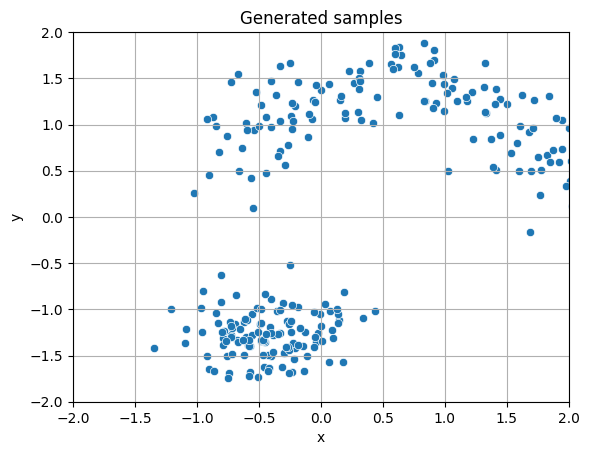

In [26]:
sns.scatterplot(x = generated_samples[:, 0].numpy(), y = generated_samples[:, 1].numpy()).set(
    xlim=(-2, 2), ylim=(-2, 2), 
    xlabel='x', ylabel='y', 
    title='Generated samples'
)
plt.grid()

From the above plot, we can clearly see that our reverse process can generate samples from our original distribution quite nicely.  
Of course, a perfect match is not possible to obtain due to the nature of a learned score function and discretization, but the results are very good.

# Conclusion

Here we have now seen the full pipeline for a score-matching based diffusion model.

In the next section, we will explore a newer paper related to how to find samples which are underrepresented in the initial data distribution.